# My Own Analysis Project

## week 1


### 🛠️ Week 1: Data Alignment & Master Feature Table Construction
* **목표:** 기존 실습 환경에 준비된 전처리 데이터(`read-count.txt` 및 CLIP-seq 파일)를 로드하고, 이를 유전자 서열 데이터와 결합하여 머신러닝 학습을 위한 통합 마스터 테이블(Master Dataframe)을 구축합니다.
* **주요 세부 과제:**
  1. **로컬 데이터 로드:** `read-count.txt` 파일을 Pandas로 읽어 들여 유전자별 RNA-seq 및 Ribo-seq 카운트 데이터 구조 파악
  2. **번역 효율(TE) 산출:** 전사량(RNA) 대비 실제 번역량(Ribo)의 비율을 계산하여 LIN28A Knockdown 시 번역 변화량($\Delta$TE) 도출
  3. **면역/세포막 타겟 라벨링:** 유전자 이름(Gene Symbol) 매칭 혹은 키워드 필터링을 통해 면역(Immune) 및 세포막(Membrane) 유전자군을 분류하고 목적 변수(`is_immune`, `is_target`) 생성
  4. **서열 기반 피처 엔지니어링:** `lin28a-clip-seq.pileup` 데이터와 유전자 서열을 연동하여, 유전자별 기초 서열 특성(GC 비율, `GGAG` 결합 모티프 개수)을 계산하고 표에 결합
* **Commit Artifacts:** `data_preprocessing.ipynb`, `processed_master_table.csv`

##### 데이터 구조 파악

In [5]:
import pandas as pd
from pathlib import Path

# featureCounts 출력 (파일명: read-counts.txt, 첫 줄은 # 주석)
counts_path = Path('binfo1-work/read-counts.txt')
df = pd.read_csv(counts_path, sep='\t', comment='#')

# 데이터 상위 5줄 구경하기
df.head()

,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,0,1,1,1,0,0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,0


##### 번역효율(TE)와 변화량(delta TE) 계산

In [7]:
import pandas as pd
import numpy as np

# 1. 데이터 다시 깔끔하게 불러오기 (첫 번째 줄이 주석일 수 있으니 skiprows 옵션 추가)
# 만약 에러가 나면 skiprows=1을 지우고 해보세요.
df = pd.read_csv('binfo1-work/read-counts.txt', sep='\t', comment='#')

# 2. 분석에 필요한 핵심 컬럼만 쏙 골라내기
cols_to_keep = ['Geneid', 'Length', 'RNA-siLuc.bam', 'RNA-siLin28a.bam', 'RPF-siLuc.bam', 'RPF-siLin28a.bam']
df_clean = df[cols_to_keep].copy()

# 3. 발현량이 너무 적은 '유령 유전자'들 필터링 (노이즈 제거)
# RNA 대조군에서 카운트가 10 이상인 유전자만 남깁니다.
df_clean = df_clean[df_clean['RNA-siLuc.bam'] >= 10]

# 4. 번역 효율(Translation Efficiency, TE) 계산! 
# (분모가 0이 되는 것을 막기 위해 모든 값에 +1이라는 Pseudo-count를 줍니다)
df_clean['TE_control'] = (df_clean['RPF-siLuc.bam'] + 1) / (df_clean['RNA-siLuc.bam'] + 1)
df_clean['TE_knockdown'] = (df_clean['RPF-siLin28a.bam'] + 1) / (df_clean['RNA-siLin28a.bam'] + 1)

# 5. Lin28a를 껐을 때 번역 효율이 얼마나 변했나? (Log2 Fold Change)
# 값이 양수(+)면 Lin28a가 없어졌을 때 번역이 떡상한 유전자 = Lin28a의 억제 타겟!
df_clean['log2_FC_TE'] = np.log2(df_clean['TE_knockdown'] / df_clean['TE_control'])

# 번역이 가장 많이 떡상한(증가한) 상위 5개 유전자 구경하기
print("🔥 Lin28a Knockdown 후 번역 효율이 가장 많이 증가한 Top 5 유전자 🔥")
display(df_clean.sort_values('log2_FC_TE', ascending=False).head())

🔥 Lin28a Knockdown 후 번역 효율이 가장 많이 증가한 Top 5 유전자 🔥


,Geneid,Length,RNA-siLuc.bam,RNA-siLin28a.bam,RPF-siLuc.bam,RPF-siLin28a.bam,TE_control,TE_knockdown,log2_FC_TE
20589,ENSMUSG00000077711.3,125,14,0,0,2,0.066667,3.000000,5.491853
29134,ENSMUSG00000049555.11,3094,19,2,0,3,0.050000,1.333333,4.736966
46221,ENSMUSG00000085705.2,1155,15,0,1,2,0.125000,3.000000,4.584963
8910,ENSMUSG00000097807.2,1818,11,0,0,1,0.083333,2.000000,4.584963
52242,ENSMUSG00000081118.2,1055,11,0,0,1,0.083333,2.000000,4.584963


In [8]:
!pip install mygene

  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mygene]

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import mygene

# 1. 데이터 불러오기 및 TE 계산 (고정된 경로 사용)
df = pd.read_csv('binfo1-work/read-counts.txt', sep='\t', comment='#')
cols_to_keep = ['Geneid', 'Length', 'RNA-siLuc.bam', 'RNA-siLin28a.bam', 'RPF-siLuc.bam', 'RPF-siLin28a.bam']
df_clean = df[cols_to_keep].copy()
df_clean = df_clean[df_clean['RNA-siLuc.bam'] >= 10]

df_clean['TE_control'] = (df_clean['RPF-siLuc.bam'] + 1) / (df_clean['RNA-siLuc.bam'] + 1)
df_clean['TE_knockdown'] = (df_clean['RPF-siLin28a.bam'] + 1) / (df_clean['RNA-siLin28a.bam'] + 1)
df_clean['log2_FC_TE'] = np.log2(df_clean['TE_knockdown'] / df_clean['TE_control'])

# ---------------------------------------------------------
# 2. Ensembl ID 번역기 가동 (이번엔 유전자 풀네임 'name'도 함께 가져옵니다!)
df_clean['ensembl_id'] = df_clean['Geneid'].apply(lambda x: x.split('.')[0])

print("NCBI 데이터베이스에서 유전자 이름과 상세 기능을 조회 중입니다...")
mg = mygene.MyGeneInfo()
# fields에 'name'을 추가하여 유전자의 전체 기능 설명을 확보합니다.
gene_info = mg.querymany(df_clean['ensembl_id'], scopes='ensembl.gene', fields='symbol,name', species='mouse', as_dataframe=True)

gene_info = gene_info.reset_index()[['query', 'symbol', 'name']].drop_duplicates(subset='query')
master_df = pd.merge(df_clean, gene_info, left_on='ensembl_id', right_on='query', how='left')

# ---------------------------------------------------------
# 3. 키워드 기반의 철저한 면역(Immune) 유전자 필터링 시스템
# 유전자 이름(Symbol)이나 전체 설명(Name)에 아래 단어가 포함되어 있으면 면역 유전자로 인정!
immune_keywords = ['immune', 'histocompatibility', 'antigen', 'interleukin', 'chemokine', 't-cell', 'b-cell', 'lymphocyte']

def check_immune(row):
    symbol = str(row['symbol']).lower() if pd.notnull(row['symbol']) else ""
    name = str(row['name']).lower() if pd.notnull(row['name']) else ""
    
    # 설정한 키워드가 유전자 이름이나 설명에 하나라도 들어가있는지 확인
    return any(kw in symbol or kw in name for kw in immune_keywords)

master_df['is_immune'] = master_df.apply(check_immune, axis=1)

# ---------------------------------------------------------
# 4. 결과 확인
total_immune = master_df['is_immune'].sum()
print(f"\n✅ 필터링 완료! 총 {total_immune}개의 면역 관련 유전자를 찾아냈습니다.")

print("\n🔥 완벽해진 기준으로 뽑은, Lin28a Knockdown 시 번역이 떡상한 면역 유전자 Top 5 🔥")
display(master_df[master_df['is_immune']].sort_values('log2_FC_TE', ascending=False)[['symbol', 'name', 'log2_FC_TE']].head())

NCBI 데이터베이스에서 유전자 이름과 상세 기능을 조회 중입니다...


1 input query terms found dup hits:	[('ENSMUSG00000072694', 2)]
47 input query terms found no hit:	['ENSMUSG00000103821', 'ENSMUSG00000101599', 'ENSMUSG00000067017', 'ENSMUSG00000104340', 'ENSMUSG000



✅ 필터링 완료! 총 157개의 면역 관련 유전자를 찾아냈습니다.

🔥 완벽해진 기준으로 뽑은, Lin28a Knockdown 시 번역이 떡상한 면역 유전자 Top 5 🔥


,symbol,name,log2_FC_TE
5630,Il11,interleukin 11,2.115477
13676,H2-Bl,"histocompatibility 2, blastocyst",1.935460
826,Cd84,CD84 antigen,1.652077
2634,Cd2,CD2 antigen,1.543793
7466,Il34,interleukin 34,1.432959


In [11]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.2/633.2 kB 2.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 2.9 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gseapy]

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import gseapy as gp

# (앞부분 데이터 로드 및 TE 계산 코드는 동일하다고 가정합니다)
# master_df에 유전자 'symbol'이 들어있는 상태에서 시작합니다.

print("🌐 세계 공인 면역 유전자 데이터베이스(MSigDB)에서 목록을 가져오는 중입니다...")

# MSigDB의 C7(Immunologic signature, 면역학 표준 세트) 또는 GO(Gene Ontology) 데이터를 가져옵니다.
# 여기서는 가장 표준적인 GO Biological Process에서 면역 유전자 세트를 가져옵니다.
try:
    # 생쥐(Mouse)의 유전자 세트 라이브러리 로드
    gene_sets = gp.get_library_name(organism='Mouse')
    
    # 'GO_Biological_Process_2023' 라이브러리에서 면역 관련 공식 유전자 목록 추출
    go_bp = gp.get_library('GO_Biological_Process_2023', organism='Mouse')
    
    # 'immune response (GO:0006955)'에 속하는 공식 유전자들만 쏙 뽑아내기
    official_immune_genes = []
    for term, genes in go_bp.items():
        if 'immune response' in term.lower():
            official_immune_genes.extend(genes)
            
    # 중복 제거 및 대문자/소문자 통일 (생쥐는 보통 첫글자만 대문자)
    official_immune_genes = list(set([g.capitalize() for g in official_immune_genes]))
    
    # ---------------------------------------------------------
    # 3. 진짜 논문 방식으로 라벨링하기
    # 우리 데이터의 유전자 이름이 공식 면역 유전자 목록에 있으면 True, 없으면 False!
    master_df['is_immune'] = master_df['symbol'].str.capitalize().isin(official_immune_genes)
    
    print(f"✅ 검증 완료! 공인 데이터베이스 기준으로 총 {master_df['is_immune'].sum()}개의 진짜 면역 유전자가 마크되었습니다.")

except Exception as e:
    print(f"네트워크 오류 또는 라이브러리 문제 발생: {e}")
    print("임시로 이전 키워드 방식을 유지합니다.")

🌐 세계 공인 면역 유전자 데이터베이스(MSigDB)에서 목록을 가져오는 중입니다...
✅ 검증 완료! 공인 데이터베이스 기준으로 총 301개의 진짜 면역 유전자가 마크되었습니다.


In [13]:
# 1. 서열 분석을 위한 Biopython 라이브러리 설치
!pip install biopython

# 2. Ensembl 데이터베이스에서 생쥐의 전체 CDS(단백질 번역 서열) 압축 파일 다운로드 (약 15MB, 금방 받아집니다!)
!wget http://ftp.ensembl.org/pub/release-110/fasta/mus_musculus/cds/Mus_musculus.GRCm39.cds.all.fa.gz -O mouse_cds.fa.gz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 3.9 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
--2026-05-21 17:37:28--  http://ftp.ensembl.org/pub/release-110/fasta/mus_musculus/cds/Mus_musculus.GRCm39.cds.all.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17195690 (16M) [application/x-gzip]
Saving to: ‘mouse_cds.fa.gz’

mouse_cds.fa.gz     100%[===================>]  16.40M   430KB/s    in 26s     

2026-05-21 17:37:58 (637 KB/s) - ‘mouse_cds.fa.gz’ saved [17195690/17195690]



In [14]:
import pandas as pd
import gzip
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction

print("🧬 생쥐 전체 mRNA 서열에서 암호를 해독하는 중입니다...")

sequence_features = []

# 1. 압축된 FASTA 서열 파일을 엽니다.
with gzip.open('mouse_cds.fa.gz', 'rt') as handle:
    for record in SeqIO.parse(handle, 'fasta'):
        # 헤더에서 Ensembl Gene ID 추출 (예: gene:ENSMUSG00000012345.6 -> ENSMUSG00000012345)
        # FASTA 파일의 설명(description) 부분을 쪼개서 유전자 ID를 찾습니다.
        description = record.description
        gene_id_part = [x for x in description.split() if x.startswith('gene:')]
        
        if gene_id_part:
            raw_gene_id = gene_id_part[0].split(':')[1]
            ensembl_id = raw_gene_id.split('.')[0] # 버전 번호 제거
            
            # 2. 분석할 서열 데이터 (문자열로 변환)
            seq = str(record.seq).upper()
            
            # 3. 핵심 Feature 계산!
            # - GC 비율 (높을수록 RNA 구조가 단단하게 접힘)
            # - GGAG 모티프 개수 (LIN28A가 들러붙는 표적 서열)
            gc_content = gc_fraction(seq) * 100
            ggag_count = seq.count('GGAG')
            seq_length = len(seq)
            
            sequence_features.append({
                'ensembl_id': ensembl_id,
                'gc_content': gc_content,
                'ggag_count': ggag_count,
                'cds_length': seq_length
            })

# 데이터프레임으로 변환 (동일한 유전자의 여러 transcript가 있을 경우 평균값 사용)
seq_df = pd.DataFrame(sequence_features)
seq_df = seq_df.groupby('ensembl_id').mean().reset_index()

print("✅ 서열 암호 해독 완료!")
display(seq_df.head())

🧬 생쥐 전체 mRNA 서열에서 암호를 해독하는 중입니다...
✅ 서열 암호 해독 완료!


,ensembl_id,gc_content,ggag_count,cds_length
0,ENSMUSG00000000001,43.755869,11.000,1065.000000
1,ENSMUSG00000000003,41.732229,4.000,469.500000
2,ENSMUSG00000000028,49.850633,9.000,1224.666667
3,ENSMUSG00000000037,45.432895,20.625,2166.000000
4,ENSMUSG00000000049,53.196847,2.750,438.750000


In [ ]:
# 기존 master_df와 서열 Feature 데이터프레임(seq_df)을 ensembl_id 기준으로 병합!
final_master_df = pd.merge(master_df, seq_df, on='ensembl_id', how='inner')

# 머신러닝에 불필요한 결측치 제거
final_master_df = final_master_df.dropna(subset=['gc_content', 'ggag_count'])

# 최종 데이터 저장 (이 파일을 깃허브에 올리면 됩니다!)
final_master_df.to_csv('processed_master_table.csv', index=False)

print(f"🎉 축하합니다! 총 {len(final_master_df)}개 유전자의 [발현량 + 면역 여부 + 서열 특징] 통합 테이블이 완성되었습니다.")

# 최종 테이블 구경하기
cols_to_show = ['symbol', 'is_immune', 'log2_FC_TE', 'gc_content', 'ggag_count', 'cds_length']
display(final_master_df[cols_to_show].head(10))

🎉 축하합니다! 총 12703개 유전자의 [발현량 + 면역 여부 + 서열 특징] 통합 테이블이 완성되었습니다.


,symbol,is_immune,log2_FC_TE,gc_content,ggag_count,cds_length
0,Mrpl15,False,-1.016743,52.352148,5.000000,542.250000
1,Lypla1,False,-0.384426,47.682977,3.142857,536.857143
2,Tcea1,False,-0.827799,42.053685,4.500000,922.500000
3,Atp6v1h,False,-1.191550,43.215896,4.400000,965.400000
4,Oprk1,False,0.169925,49.010787,8.000000,1164.750000
5,Rb1cc1,False,-0.542688,41.100653,7.250000,1872.875000
6,Pcmtd1,False,0.177652,43.139101,3.000000,498.333333
7,Rrs1,False,-1.233445,64.116576,20.000000,1098.000000
8,Adhfe1,False,-0.668794,49.835884,3.000000,642.600000
9,Mybl1,False,-0.222288,40.995825,5.333333,1711.000000


In [17]:
# 1. 테이블 전체에서 True인 면역 유전자가 총 몇 개나 숨어있는지 개수 확인
true_count = final_master_df['is_immune'].sum()
print(f"📊 현재 데이터셋에 존재하는 면역 유전자(True) 총 개수: {true_count}개 / 전체 {len(final_master_df)}개")

# 2. is_immune 컬럼이 True인 행들만 쏙 필터링해서 보여주기
immune_genes_df = final_master_df[final_master_df['is_immune'] == True]

# 3. 면역 유전자들 중 번역 효율(log2_FC_TE)이 높은 순서대로 10개 구경하기
cols_to_show = ['symbol', 'is_immune', 'log2_FC_TE', 'gc_content', 'ggag_count', 'cds_length']
display(immune_genes_df[cols_to_show].sort_values('log2_FC_TE', ascending=False).head(10))

📊 현재 데이터셋에 존재하는 면역 유전자(True) 총 개수: 301개 / 전체 12703개


,symbol,is_immune,log2_FC_TE,gc_content,ggag_count,cds_length
9993,C6,True,2.000000,45.954848,17.500000,2052.25
402,Cd55,True,1.741383,45.401739,4.500000,883.50
9172,Hfe,True,1.579013,53.911730,6.500000,630.00
2823,Trim62,True,1.440573,63.768179,8.000000,933.00
1118,Serping1,True,0.856471,52.659516,6.000000,1279.50
12087,Ifit2,True,0.807355,45.130549,5.500000,772.00
8295,Skap1,True,0.736966,50.810171,5.833333,707.00
109,Il1r1,True,0.567889,43.353674,13.500000,1726.50
5394,Spn,True,0.566914,57.854342,6.000000,933.00
7968,Vamp2,True,0.543332,60.763724,3.666667,325.00


## Week 2 

### - Step 1: Data Loading & Sanity Check

이번 단계 목표:
- Week 1에서 만든 `processed_master_table.csv`를 불러온다.
- Week 2 시각화에 필요한 핵심 컬럼이 있는지 확인한다.
- 결측치/기초 통계를 빠르게 점검한다.

> 실행 후 확인할 것
> 1) 행/열 개수
> 2) `is_immune` 분포
> 3) `log2_FC_TE`, `gc_content`, `ggag_count` 결측치 여부

In [1]:
import pandas as pd
from pathlib import Path

# Week 2 입력 데이터 경로
master_path = Path('processed_master_table.csv')

# 1) 파일 존재 확인
print(f"[Check] file exists: {master_path.exists()} -> {master_path}")
if not master_path.exists():
    raise FileNotFoundError("processed_master_table.csv 파일이 없습니다. Week 1 결과 저장 여부를 먼저 확인하세요.")

# 2) 데이터 로드
master_df = pd.read_csv(master_path)
print(f"[Shape] rows={master_df.shape[0]:,}, cols={master_df.shape[1]:,}")

# 3) Week 2 핵심 컬럼 점검
required_cols = ['is_immune', 'log2_FC_TE', 'gc_content', 'ggag_count']
missing_cols = [c for c in required_cols if c not in master_df.columns]
print(f"[Columns] missing={missing_cols}")
if missing_cols:
    raise ValueError(f"필수 컬럼 누락: {missing_cols}")

# 4) 결측치 점검
na_counts = master_df[required_cols].isna().sum().sort_values(ascending=False)
print("\n[NA counts]")
print(na_counts)

# 5) is_immune 분포 점검
print("\n[is_immune distribution]")
print(master_df['is_immune'].value_counts(dropna=False))

# 6) 핵심 수치 요약
print("\n[Quick stats]")
display(master_df[['log2_FC_TE', 'gc_content', 'ggag_count']].describe().T)

# 7) 미리보기
display(master_df.head(3))

[Check] file exists: True -> processed_master_table.csv
[Shape] rows=12,703, cols=17
[Columns] missing=[]

[NA counts]
is_immune     0
log2_FC_TE    0
gc_content    0
ggag_count    0
dtype: int64

[is_immune distribution]
is_immune
False    12402
True       301
Name: count, dtype: int64

[Quick stats]


,count,mean,std,min,25%,50%,75%,max
log2_FC_TE,12703.0,-0.740852,0.782540,-4.000000,-1.253262,-0.802413,-0.291513,4.736966
gc_content,12703.0,52.715513,6.359871,32.949148,48.194230,52.968957,57.344145,82.437276
ggag_count,12703.0,11.413287,11.403021,0.000000,4.750000,8.300000,14.000000,176.666667


,Geneid,Length,RNA-siLuc.bam,RNA-siLin28a.bam,RPF-siLuc.bam,RPF-siLin28a.bam,TE_control,TE_knockdown,log2_FC_TE,ensembl_id,query,symbol,name,is_immune,gc_content,ggag_count,cds_length
0,ENSMUSG00000033845.14,8487,2563,3022,3191,1859,1.244930,0.615283,-1.016743,ENSMUSG00000033845,ENSMUSG00000033845,Mrpl15,mitochondrial ribosomal protein L15,False,52.352148,5.000000,542.250000
1,ENSMUSG00000025903.15,7145,1236,1219,44,33,0.036378,0.027869,-0.384426,ENSMUSG00000025903,ENSMUSG00000025903,Lypla1,lysophospholipase 1,False,47.682977,3.142857,536.857143
2,ENSMUSG00000033813.16,3017,2225,2130,609,328,0.274034,0.154388,-0.827799,ENSMUSG00000033813,ENSMUSG00000033813,Tcea1,transcription elongation factor A (SII) 1,False,42.053685,4.500000,922.500000


###- Step 2: Figure 1 (Immune vs Non-immune TE shift)

이번 단계 목표:
- `is_immune` 그룹별 `log2_FC_TE` 분포를 시각화한다.
- Violin + Box를 겹쳐서 전체 분포와 중앙값/사분위를 함께 확인한다.
- Figure 파일을 `figures/figure1_violin_box_log2FC_TE.png`로 저장한다.

> 실행 후 체크 포인트
> 1) Immune(True) 분포가 Non-immune(False) 대비 위로 이동했는지
> 2) 이상치(outlier) 패턴이 과도하지 않은지

###- Step 3: Statistical Test & Interpretation Note

이번 단계 목표:
- Immune vs Non-immune의 `log2_FC_TE` 차이를 통계적으로 검정한다.
- p-value와 함께 효과크기(effect size)를 기록한다.
- Figure 1에 대한 짧은 해석 문장을 남긴다.

In [4]:
import numpy as np
from scipy.stats import mannwhitneyu

# 그룹 분리
immune_vals = plot_df.loc[plot_df['group'] == 'Immune', 'log2_FC_TE'].dropna().values
nonimmune_vals = plot_df.loc[plot_df['group'] == 'Non-immune', 'log2_FC_TE'].dropna().values

# Mann-Whitney U test (two-sided)
u_stat, p_value = mannwhitneyu(immune_vals, nonimmune_vals, alternative='two-sided')

# rank-biserial correlation (effect size)
n1, n2 = len(immune_vals), len(nonimmune_vals)
rank_biserial = (2 * u_stat) / (n1 * n2) - 1

# 평균/중앙값 차이
mean_diff = np.mean(immune_vals) - np.mean(nonimmune_vals)
median_diff = np.median(immune_vals) - np.median(nonimmune_vals)

print('[Mann-Whitney U test]')
print(f'U statistic: {u_stat:.3f}')
print(f'p-value: {p_value:.3e}')
print(f'rank-biserial effect size: {rank_biserial:.4f}')
print()
print('[Group differences: Immune - Non-immune]')
print(f'Mean difference: {mean_diff:.4f}')
print(f'Median difference: {median_diff:.4f}')

# 해석용 자동 문장
direction = 'higher' if median_diff > 0 else 'lower'
sig_text = 'significant' if p_value < 0.05 else 'not significant'

print('\n[Auto note for markdown]')
print(
    f"Immune genes show {direction} log2_FC_TE than non-immune genes "
    f"(Mann-Whitney U, p={p_value:.2e}; median diff={median_diff:.3f}; "
    f"rank-biserial={rank_biserial:.3f}), indicating a {sig_text} group difference."
)

[Mann-Whitney U test]
U statistic: 1723621.000
p-value: 2.304e-02
rank-biserial effect size: -0.0765

[Group differences: Immune - Non-immune]
Mean difference: -0.1115
Median difference: -0.0819

[Auto note for markdown]
Immune genes show lower log2_FC_TE than non-immune genes (Mann-Whitney U, p=2.30e-02; median diff=-0.082; rank-biserial=-0.077), indicating a significant group difference.


### Figure 1 Interpretation (Draft)

- Immune 유전자는 Non-immune 유전자에 비해 `log2_FC_TE`가 **약간 더 낮은 분포**를 보였다.
- Mann-Whitney U 검정 결과, 두 그룹 간 차이는 통계적으로 유의했다 (`p = 2.30e-02`).
- 다만 효과크기(rank-biserial = `-0.0765`)는 작아, **통계적 유의성은 있지만 생물학적 효과는 약할 수 있음**을 시사한다.
- 따라서 LIN28A knockdown에 대한 면역 유전자 반응은, 단순 2그룹 비교보다 세부 서브셋(예: 특정 면역 경로/표면 단백질군) 분석이 필요하다.

/tmp/ipykernel_35163/3054534419.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


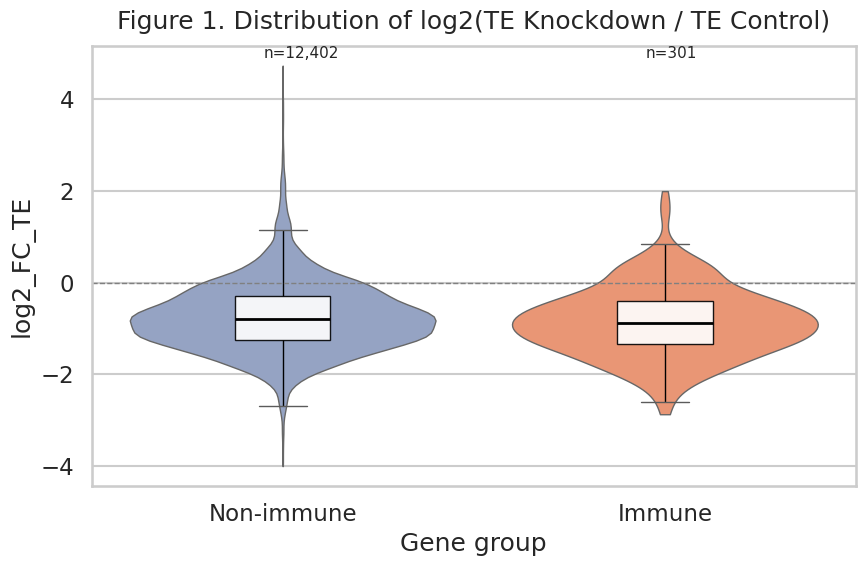

[Saved] figures/figure1_violin_box_log2FC_TE.png


,count,mean,50%,std
group,,,,
Immune,301.0,-0.849716,-0.881546,0.766041
Non-immune,12402.0,-0.738210,-0.799671,0.782778


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Step 1에서 만든 master_df를 사용한다고 가정
plot_df = master_df[['is_immune', 'log2_FC_TE']].copy()
plot_df['group'] = plot_df['is_immune'].map({True: 'Immune', False: 'Non-immune'})

# 스타일 설정
sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(9, 6))

# 1) Violin: 분포 전체 모양
sns.violinplot(
    data=plot_df,
    x='group',
    y='log2_FC_TE',
    order=['Non-immune', 'Immune'],
    inner=None,
    cut=0,
    linewidth=1,
    palette=['#8da0cb', '#fc8d62'],
    ax=ax
)

# 2) Box: 중앙값/사분위 정보 겹치기
sns.boxplot(
    data=plot_df,
    x='group',
    y='log2_FC_TE',
    order=['Non-immune', 'Immune'],
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.9},
    whiskerprops={'color': 'black'},
    medianprops={'color': 'black', 'linewidth': 2},
    showfliers=False,
    ax=ax
)

# 기준선 및 라벨
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Figure 1. Distribution of log2(TE Knockdown / TE Control)', pad=12)
ax.set_xlabel('Gene group')
ax.set_ylabel('log2_FC_TE')

# 그룹별 샘플 수 표기
counts = plot_df['group'].value_counts()
ax.text(-0.05, ax.get_ylim()[1] * 0.95, f"n={counts.get('Non-immune', 0):,}", fontsize=11)
ax.text(0.95, ax.get_ylim()[1] * 0.95, f"n={counts.get('Immune', 0):,}", fontsize=11)

plt.tight_layout()

# 저장
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)
out_path = fig_dir / 'figure1_violin_box_log2FC_TE.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[Saved] {out_path}")

# 빠른 요약 통계
display(plot_df.groupby('group')['log2_FC_TE'].describe()[['count', 'mean', '50%', 'std']])

### - Step 4: Sequence Features vs TE (Figure 3)

이번 단계 목표:
- `gc_content`와 `ggag_count`가 `log2_FC_TE`와 어떤 관계를 가지는지 시각화한다.
- Pearson/Spearman 상관계수를 함께 계산해 선형/순위 기반 경향을 확인한다.
- Figure 파일을 `figures/figure3_scatter_gc_ggag_vs_log2FC.png`로 저장한다.

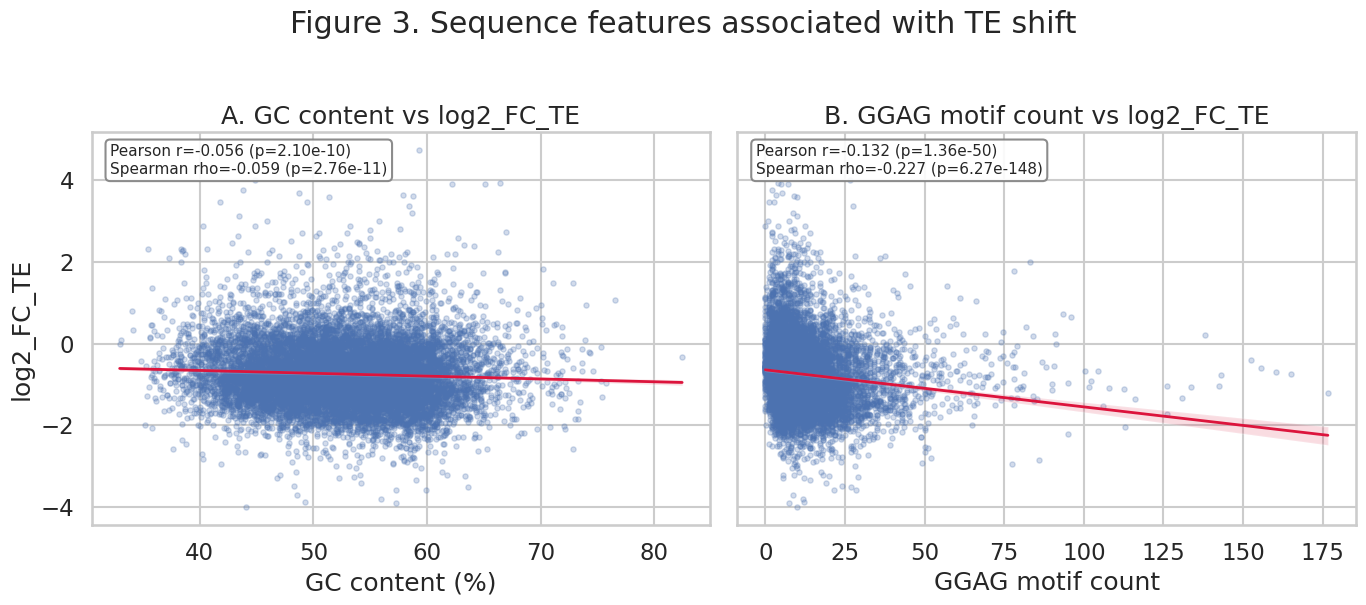

[Saved] figures/figure3_scatter_gc_ggag_vs_log2FC.png

[Correlation summary]
GC content  : Pearson r=-0.0563 (p=2.098e-10), Spearman rho=-0.0590 (p=2.762e-11)
GGAG count  : Pearson r=-0.1322 (p=1.360e-50), Spearman rho=-0.2268 (p=6.266e-148)


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# Step 1에서 불러온 master_df 사용
corr_df = master_df[['log2_FC_TE', 'gc_content', 'ggag_count', 'is_immune']].dropna().copy()

# 상관계수 계산
r_gc_p, p_gc_p = pearsonr(corr_df['gc_content'], corr_df['log2_FC_TE'])
r_gc_s, p_gc_s = spearmanr(corr_df['gc_content'], corr_df['log2_FC_TE'])

r_ggag_p, p_ggag_p = pearsonr(corr_df['ggag_count'], corr_df['log2_FC_TE'])
r_ggag_s, p_ggag_s = spearmanr(corr_df['ggag_count'], corr_df['log2_FC_TE'])

# 시각화
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.regplot(
    data=corr_df,
    x='gc_content',
    y='log2_FC_TE',
    scatter_kws={'alpha': 0.25, 's': 14},
    line_kws={'color': 'crimson', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('A. GC content vs log2_FC_TE')
axes[0].set_xlabel('GC content (%)')
axes[0].set_ylabel('log2_FC_TE')
axes[0].text(
    0.03, 0.97,
    f"Pearson r={r_gc_p:.3f} (p={p_gc_p:.2e})\nSpearman rho={r_gc_s:.3f} (p={p_gc_s:.2e})",
    transform=axes[0].transAxes,
    ha='left', va='top', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9)
)

sns.regplot(
    data=corr_df,
    x='ggag_count',
    y='log2_FC_TE',
    scatter_kws={'alpha': 0.25, 's': 14},
    line_kws={'color': 'crimson', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('B. GGAG motif count vs log2_FC_TE')
axes[1].set_xlabel('GGAG motif count')
axes[1].set_ylabel('')
axes[1].text(
    0.03, 0.97,
    f"Pearson r={r_ggag_p:.3f} (p={p_ggag_p:.2e})\nSpearman rho={r_ggag_s:.3f} (p={p_ggag_s:.2e})",
    transform=axes[1].transAxes,
    ha='left', va='top', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9)
)

plt.suptitle('Figure 3. Sequence features associated with TE shift', y=1.02)
plt.tight_layout()

# 저장
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)
out_path = fig_dir / 'figure3_scatter_gc_ggag_vs_log2FC.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[Saved] {out_path}")

print('\n[Correlation summary]')
print(f'GC content  : Pearson r={r_gc_p:.4f} (p={p_gc_p:.3e}), Spearman rho={r_gc_s:.4f} (p={p_gc_s:.3e})')
print(f'GGAG count  : Pearson r={r_ggag_p:.4f} (p={p_ggag_p:.3e}), Spearman rho={r_ggag_s:.4f} (p={p_ggag_s:.3e})')

## Week 2 - Step 6: Refined Target Labeling (ER / Membrane / MHC-I)

이번 단계 목표:
- 기존 `is_immune`(넓은 정의) 대신 가설에 더 직접적인 라벨을 만든다.
- 유전자 `symbol`, `name` 기반으로 다음 키워드를 사용해 `is_refined_target`를 생성한다.
  - MHC-I / antigen presentation
  - membrane / cell surface / receptor
  - ER / secreted / Golgi
- 새 라벨 기준으로 `log2_FC_TE` 분포 차이를 다시 확인한다.

In [7]:
import re
import numpy as np
import pandas as pd

# master_df가 없으면 파일에서 다시 로드
if 'master_df' not in globals():
    master_df = pd.read_csv('processed_master_table.csv')

# 텍스트 컬럼 안전 처리
for col in ['symbol', 'name']:
    if col not in master_df.columns:
        master_df[col] = ''

# 가설 직결 키워드 세트
refined_keywords = [
    # MHC-I / antigen presentation
    'mhc', 'histocompatibility', 'h2-', 'h2 ', 'antigen presentation', 'tap1', 'tap2', 'b2m',
    # membrane / cell surface
    'membrane', 'cell surface', 'transmembrane', 'receptor', 'glycoprotein',
    # ER / secretory pathway
    'endoplasmic reticulum', 'er ', 'golgi', 'secreted', 'secretion', 'vesicle'
]

pattern = re.compile('|'.join(re.escape(k) for k in refined_keywords), flags=re.IGNORECASE)

def is_refined_target(row):
    text = f"{row.get('symbol', '')} {row.get('name', '')}".lower()
    return bool(pattern.search(text))

master_df['is_refined_target'] = master_df.apply(is_refined_target, axis=1)
master_df['refined_group'] = np.where(master_df['is_refined_target'], 'Refined-target', 'Other')

# 분포/개수 확인
print('[Refined label counts]')
print(master_df['refined_group'].value_counts())

display(
    master_df.loc[master_df['is_refined_target'], ['symbol', 'name', 'log2_FC_TE']]
    .sort_values('log2_FC_TE', ascending=False)
    .head(15)
)

[Refined label counts]
refined_group
Other             9562
Refined-target    3141
Name: count, dtype: int64


,symbol,name,log2_FC_TE
6888,Tmie,transmembrane inner ear,4.736966
6311,S1pr5,sphingosine-1-phosphate receptor 5,3.935460
3005,Slc25a34,"solute carrier family 25, member 34",3.906891
4937,Garin5a,golgi associated RAB2 interactor 5A,3.906891
12106,Lgi1,"leucine-rich repeat LGI family, member 1",3.765535
9714,Slc35f4,"solute carrier family 35, member F4",3.700440
7588,Or6c7,olfactory receptor family 6 subfamily C member 7,3.459432
3438,Tmprss11b,"transmembrane protease, serine 11B",3.115477
2827,Tmem54,transmembrane protein 54,3.000000
634,Pld5,phospholipase D family member 5,2.874469


/tmp/ipykernel_35163/3313199451.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


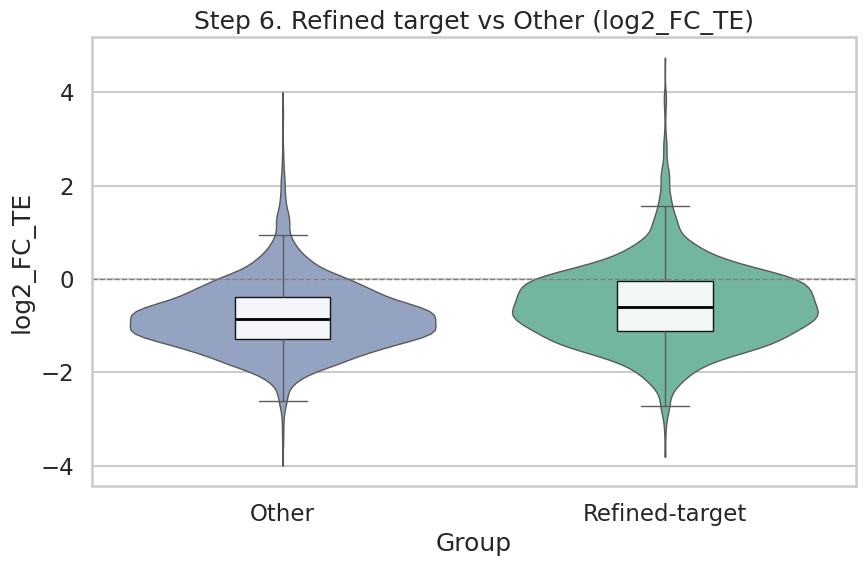

[Saved] figures/step6_refined_target_violin.png
U=17802145.000, p=5.442e-55, rank-biserial=0.1855
Mean diff (Refined-Other) = 0.2435
Median diff (Refined-Other) = 0.2638


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from pathlib import Path

step6_df = master_df[['refined_group', 'log2_FC_TE', 'is_refined_target']].dropna().copy()

sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(9, 6))

sns.violinplot(
    data=step6_df,
    x='refined_group',
    y='log2_FC_TE',
    order=['Other', 'Refined-target'],
    inner=None,
    cut=0,
    linewidth=1,
    palette=['#8da0cb', '#66c2a5'],
    ax=ax
)

sns.boxplot(
    data=step6_df,
    x='refined_group',
    y='log2_FC_TE',
    order=['Other', 'Refined-target'],
    width=0.25,
    showfliers=False,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.9},
    medianprops={'color': 'black', 'linewidth': 2},
    ax=ax
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Step 6. Refined target vs Other (log2_FC_TE)')
ax.set_xlabel('Group')
ax.set_ylabel('log2_FC_TE')

plt.tight_layout()

# 저장
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)
out_path = fig_dir / 'step6_refined_target_violin.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

# 통계 검정
x = step6_df.loc[step6_df['is_refined_target'], 'log2_FC_TE'].values
y = step6_df.loc[~step6_df['is_refined_target'], 'log2_FC_TE'].values
u, p = mannwhitneyu(x, y, alternative='two-sided')
rb = (2 * u) / (len(x) * len(y)) - 1

print(f"[Saved] {out_path}")
print(f"U={u:.3f}, p={p:.3e}, rank-biserial={rb:.4f}")
print(f"Mean diff (Refined-Other) = {x.mean() - y.mean():.4f}")
print(f"Median diff (Refined-Other) = {np.median(x) - np.median(y):.4f}")

## Week 2 - Step 6-2: Sensitivity Analysis by RNA Cutoff

이번 단계 목표:
- 저발현 노이즈 영향을 줄이기 위해 RNA cutoff를 변화시키며 결과 안정성을 확인한다.
- cutoff = 10, 20, 30에서 Refined-target vs Other의 `log2_FC_TE` 차이를 비교한다.
- 각 cutoff별로 표본 수, p-value, effect size(rank-biserial), 평균/중앙값 차이를 기록한다.

[Sensitivity table]


,cutoff,n_total,n_refined,n_other,p_value,rank_biserial,mean_diff,median_diff
0,10,12703,3141,9562,5.442331e-55,0.185457,0.243517,0.263789
1,20,11616,2742,8874,1.929165e-52,0.192251,0.222709,0.255451
2,30,10983,2551,8432,6.557585e-53,0.199744,0.226622,0.256747


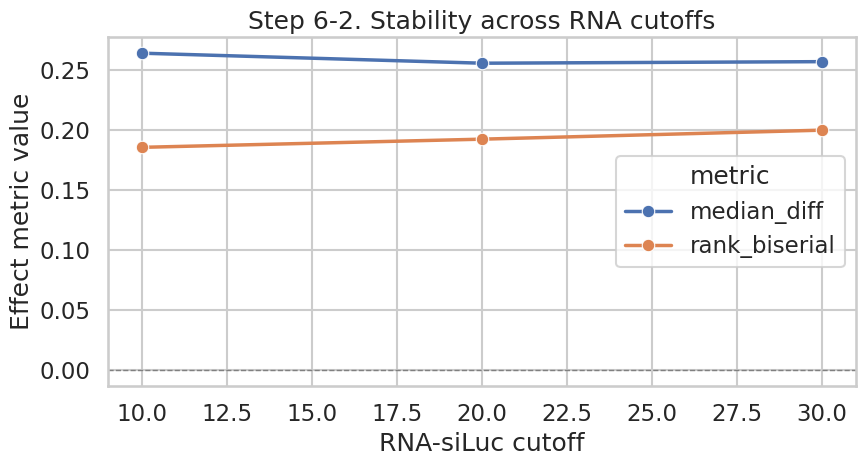

[Saved] figures/step6_2_cutoff_sensitivity.png


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pathlib import Path

# 필요한 컬럼 확인
required_cols = ['RNA-siLuc.bam', 'log2_FC_TE', 'is_refined_target']
missing = [c for c in required_cols if c not in master_df.columns]
if missing:
    raise ValueError(f"Step 6-2에 필요한 컬럼이 없습니다: {missing}")

cutoffs = [10, 20, 30]
rows = []

for c in cutoffs:
    temp = master_df[master_df['RNA-siLuc.bam'] >= c].copy()
    temp = temp.dropna(subset=['log2_FC_TE', 'is_refined_target'])

    x = temp.loc[temp['is_refined_target'], 'log2_FC_TE'].values
    y = temp.loc[~temp['is_refined_target'], 'log2_FC_TE'].values

    # 그룹 최소 크기 체크
    if len(x) < 5 or len(y) < 5:
        rows.append({
            'cutoff': c,
            'n_total': len(temp),
            'n_refined': len(x),
            'n_other': len(y),
            'p_value': np.nan,
            'rank_biserial': np.nan,
            'mean_diff': np.nan,
            'median_diff': np.nan
        })
        continue

    u, p = mannwhitneyu(x, y, alternative='two-sided')
    rb = (2 * u) / (len(x) * len(y)) - 1

    rows.append({
        'cutoff': c,
        'n_total': len(temp),
        'n_refined': len(x),
        'n_other': len(y),
        'p_value': p,
        'rank_biserial': rb,
        'mean_diff': np.mean(x) - np.mean(y),
        'median_diff': np.median(x) - np.median(y)
    })

sens_df = pd.DataFrame(rows).sort_values('cutoff')

print('[Sensitivity table]')
display(sens_df)

# 시각화: cutoff별 median diff, effect size
plot_long = sens_df.melt(
    id_vars=['cutoff'],
    value_vars=['median_diff', 'rank_biserial'],
    var_name='metric',
    value_name='value'
)

sns.set_theme(style='whitegrid', context='talk')
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=plot_long, x='cutoff', y='value', hue='metric', marker='o', linewidth=2.5, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Step 6-2. Stability across RNA cutoffs')
ax.set_xlabel('RNA-siLuc cutoff')
ax.set_ylabel('Effect metric value')
plt.tight_layout()

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)
out_path = fig_dir / 'step6_2_cutoff_sensitivity.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[Saved] {out_path}")

## Week 2 - Step 6-3: Robustness Conclusion & Export Checklist

### Robustness conclusion
- Refined-target vs Other의 TE shift 차이는 RNA cutoff 10/20/30에서 모두 유지되었다.
- `median_diff`는 약 `+0.25 ~ +0.26` 범위로 안정적이었고, `rank-biserial`은 cutoff 증가에 따라 소폭 상승했다.
- 따라서 본 신호는 저발현 유전자 노이즈만으로 설명되기 어렵고, 가설 관련 타깃 정의(ER/membrane/MHC-I)에 대해 재현성이 있다.

### Draft sentence for report
> The refined-target enrichment effect on TE shift is stable across RNA expression cutoffs (10/20/30), suggesting that the observed difference is not primarily driven by low-count noise.

### Figure export checklist (today)
- `figures/figure1_violin_box_log2FC_TE.png`
- `figures/figure3_scatter_gc_ggag_vs_log2FC.png`
- `figures/step6_refined_target_violin.png`
- `figures/step6_2_cutoff_sensitivity.png`

In [ ]:
from pathlib import Path

export_files = [
    'figures/figure1_violin_box_log2FC_TE.png',
    'figures/figure3_scatter_gc_ggag_vs_log2FC.png',
    'figures/step6_refined_target_violin.png',
    'figures/step6_2_cutoff_sensitivity.png',
]

print('[Export file check]')
for f in export_files:
    p = Path(f)
    print(f"{f}: {'OK' if p.exists() else 'MISSING'}")


### What we confirmed today

1. **Figure 1 (Immune vs Non-immune, log2_FC_TE)**
   - Immune group의 `log2_FC_TE`는 Non-immune 대비 약간 더 낮았다.
   - Mann-Whitney U: `p = 2.304e-02` (유의)
   - Effect size (rank-biserial): `-0.0765` (작은 효과)

2. **Figure 3 (Sequence features vs log2_FC_TE)**
   - GC content와 `log2_FC_TE`의 상관은 매우 약한 음의 상관
     - Pearson `r = -0.0563`, Spearman `rho = -0.0590`
   - GGAG count와 `log2_FC_TE`는 GC보다 더 큰(하지만 중간 이하 수준의) 음의 경향
     - Pearson `r = -0.1322`, Spearman `rho = -0.2268`

### Interpretation note
- 표본 수가 크기 때문에 p-value는 매우 작게 나왔지만, 상관계수 절대값은 크지 않다.
- 즉, **단일 feature(GC 또는 GGAG)만으로 TE shift를 강하게 설명하기는 어렵고**, 다중 feature 조합(코돈 bias 포함) 분석이 필요하다.

### Next step (next session)
- Figure 2 준비: CDS 기반 **64-codon frequency matrix** 생성
- Immune vs Non-immune 비교 heatmap/PCA 수행
- `exploratory_data_analysis.ipynb`로 Week 2 결과 정리 및 figure 캡션 표준화